# Predicting Residential Property Condition from Real Estate Features

**Author:** Samir Kerkar  
**University of California, Irvine — B.S. Mathematics**

---

## Objective

Property condition assessment is traditionally a manual, subjective process conducted during home inspections. This notebook explores whether machine learning models can predict a home's **condition grade (0–4)** from publicly available real estate attributes — square footage, year built, bedrooms, lot size, and location.

This is a **multiclass classification** problem with significant **class imbalance** (most homes fall in condition grades 2–3). We walk through:

1. Exploratory data analysis and outlier handling
2. Feature engineering (geospatial neighborhood features)
3. Feature selection (mutual information, PCA)
4. Model comparison across 8 classifiers
5. Addressing class imbalance via downsampling and oversampling

**Training period:** 2014 data → **Testing on:** 2015 data (temporal validation)

---
## 1. Setup and Imports

In [1]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier, XGBRegressor

# Resampling
from sklearn.utils import resample
from imblearn.over_sampling import RandomOverSampler

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, f1_score
)
from sklearn.model_selection import cross_val_score, cross_validate

# Plot settings
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
COLORS = ['#2E86AB', '#A23B72', '#F18F01', '#2CA58D', '#E84855']
sns.set_palette(COLORS)

print('All libraries loaded.')

C:\Users\smore\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\smore\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
C:\Users\smore\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


All libraries loaded.


---
## 2. Data Loading and Initial Inspection

In [2]:
# Load dataset
df = pd.read_excel(r'C:\Users\smore\Downloads\test_dataset.xlsx', parse_dates=['date'])
df = df.drop('id', axis=1)

# Extract date features
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day of week'] = df['date'].dt.dayofweek

# Shift condition from 1-5 to 0-4 for zero-indexed classification
df['condition'] = df['condition '] - 1
df = df.drop('condition ', axis=1)

print(f'Dataset shape: {df.shape}')
print(f'Date range: {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Missing values: {df.isna().sum().sum()}')
df = df.dropna()
df['condition'] = df['condition'].astype(int)
print(f'After dropping NAs: {df.shape}')
df.head()

Dataset shape: (21619, 16)
Date range: 2014-05-02 to 2015-05-27
Missing values: 26
After dropping NAs: (21596, 16)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_basement,yr_built,yr_renovated,lat,long,year,month,day of week,condition
1,2014-12-09,538000.0,3,2.25,2570,7242,2.0,400.0,1951,1991.0,47.7210,-122.319,2014,12,1,2
3,2014-12-09,604000.0,4,3.00,1960,5000,1.0,910.0,1965,0.0,47.5208,-122.393,2014,12,1,4
5,2014-05-12,1230000.0,4,4.50,5420,101930,1.0,1530.0,2001,0.0,47.6561,-122.005,2014,5,0,2
8,2015-04-15,229500.0,3,1.00,1780,7470,1.0,730.0,1960,0.0,47.5123,-122.337,2015,4,2,2
9,2015-03-12,323000.0,3,2.50,1890,6560,2.0,0.0,2003,0.0,47.3684,-122.031,2015,3,3,2


---
## 3. Exploratory Data Analysis

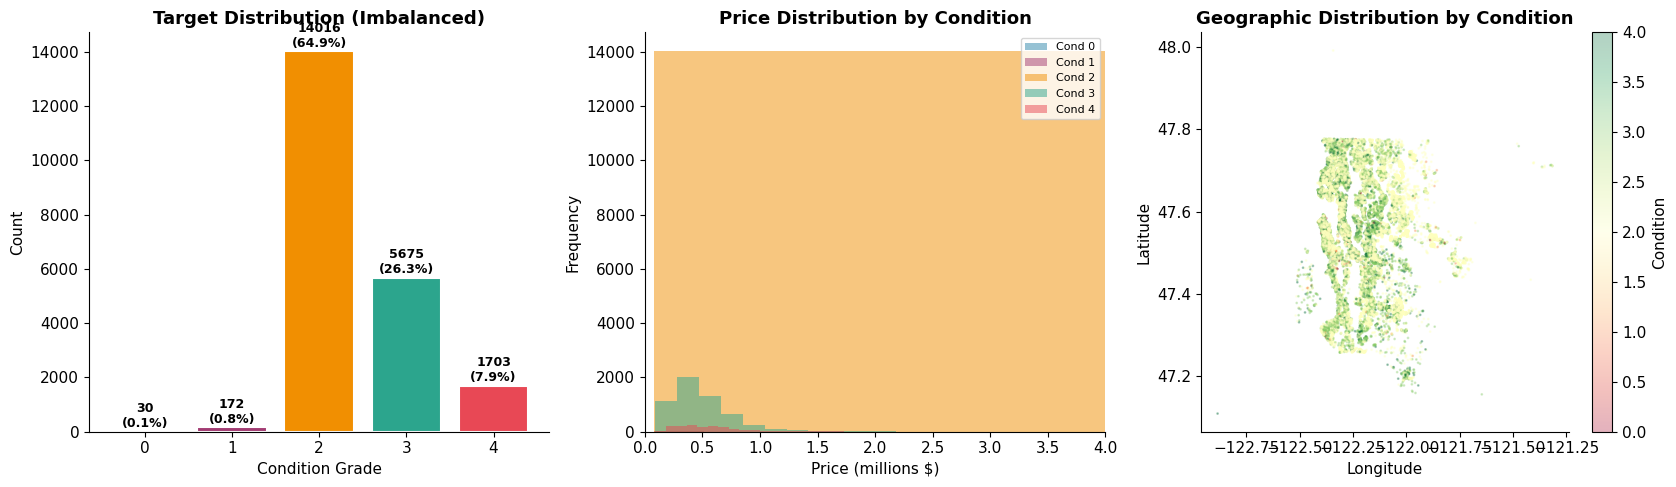

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Target distribution
counts = df['condition'].value_counts().sort_index()
bars = axes[0].bar(counts.index, counts.values, color=COLORS, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
                 f'{val}\n({val/len(df):.1%})', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xlabel('Condition Grade')
axes[0].set_ylabel('Count')
axes[0].set_title('Target Distribution (Imbalanced)', fontweight='bold')

# Price distribution by condition
for cond in sorted(df['condition'].unique()):
    subset = df[df['condition'] == cond]['price'] / 1e6
    axes[1].hist(subset, bins=40, alpha=0.5, label=f'Cond {cond}', color=COLORS[cond])
axes[1].set_xlabel('Price (millions $)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Price Distribution by Condition', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].set_xlim(0, 4)

# Geographic distribution
scatter = axes[2].scatter(df['long'], df['lat'], c=df['condition'], cmap='RdYlGn',
                          s=1, alpha=0.3)
axes[2].set_xlabel('Longitude')
axes[2].set_ylabel('Latitude')
axes[2].set_title('Geographic Distribution by Condition', fontweight='bold')
plt.colorbar(scatter, ax=axes[2], label='Condition')

plt.tight_layout()
plt.show()

In [4]:
# Descriptive statistics
print('Dataset summary:')
df.describe().round(2)

Dataset summary:


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,sqft_basement,yr_built,yr_renovated,lat,long,year,month,day of week,condition
count,21596,2.159600e+04,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00,21596.00
mean,2014-10-29 03:49:30.550101760,5.866343e+05,3.37,2.12,2080.53,15116.46,1.49,291.80,1971.00,84.47,47.56,-122.21,2014.32,6.58,2.01,2.41
min,2014-05-02 00:00:00,5.000000e+00,0.00,0.00,290.00,520.00,1.00,0.00,1900.00,0.00,47.11,-122.88,2014.00,1.00,0.00,0.00
25%,2014-07-22 00:00:00,3.220000e+05,3.00,1.75,1430.00,5040.00,1.00,0.00,1951.00,0.00,47.47,-122.33,2014.00,4.00,1.00,2.00
50%,2014-10-16 00:00:00,4.500000e+05,3.00,2.25,1910.00,7620.00,1.50,0.00,1975.00,0.00,47.57,-122.23,2014.00,6.00,2.00,2.00
75%,2015-02-17 00:00:00,6.450000e+05,4.00,2.50,2550.00,10696.25,2.00,560.00,1997.00,0.00,47.68,-122.12,2015.00,9.00,3.00,3.00
max,2015-05-27 00:00:00,1.000000e+09,33.00,8.00,13540.00,1651359.00,5.00,4820.00,2015.00,2015.00,47.99,-121.32,2015.00,12.00,6.00,4.00
std,NaN,6.811011e+06,0.93,0.77,918.89,41438.06,0.54,442.83,29.38,401.83,0.14,0.14,0.47,3.11,1.46,0.65


### 3.1 Outlier Detection and Removal

In [5]:
# Identify outliers
print('Potential outliers:')
print(f'  Max bedrooms: {df["bedrooms"].max()} (row {df["bedrooms"].idxmax()})')
print(f'  Max price: ${df["price"].max():,.0f}')
print(f'  Min price: ${df["price"].min():,.0f}')

# Fix: house with 33 bedrooms is likely a data entry error (should be 3)
df['bedrooms'] = df['bedrooms'].replace(33, 3)

# Remove house that sold for $5 (clearly erroneous)
df = df[df['price'] != 5]

print(f'\nAfter cleaning: {len(df)} rows')

Potential outliers:
  Max bedrooms: 33 (row 15876)
  Max price: $999,999,999
  Min price: $5

After cleaning: 21595 rows


---
## 4. Feature Engineering

A home's condition is likely influenced by its **neighborhood** — properties in well-maintained areas tend to be in better condition. We create geospatial features by computing the average characteristics of nearby homes within a 0.01° radius (~1 km).

In [7]:
def find_avg(row, df, column, radius=0.01):
    """Compute average of `column` for nearby properties within `radius` degrees."""
    nearby = df[
        (np.abs(df['lat'] - row['lat']) < radius) &
        (np.abs(df['long'] - row['long']) < radius)
    ]
    return nearby[column].mean()

# Engineer neighborhood features (this takes a moment)
print('Engineering neighborhood features...')
for col in ['price', 'sqft_living', 'yr_built', 'sqft_lot']:
    df[f'avg_nearby_{col}'] = df.apply(lambda row: find_avg(row, df, col), axis=1)
    print(f'  ✓ avg_nearby_{col}')

print(f'\nNew feature count: {df.shape[1]}')

Engineering neighborhood features...
  ✓ avg_nearby_price
  ✓ avg_nearby_sqft_living
  ✓ avg_nearby_yr_built
  ✓ avg_nearby_sqft_lot

New feature count: 20


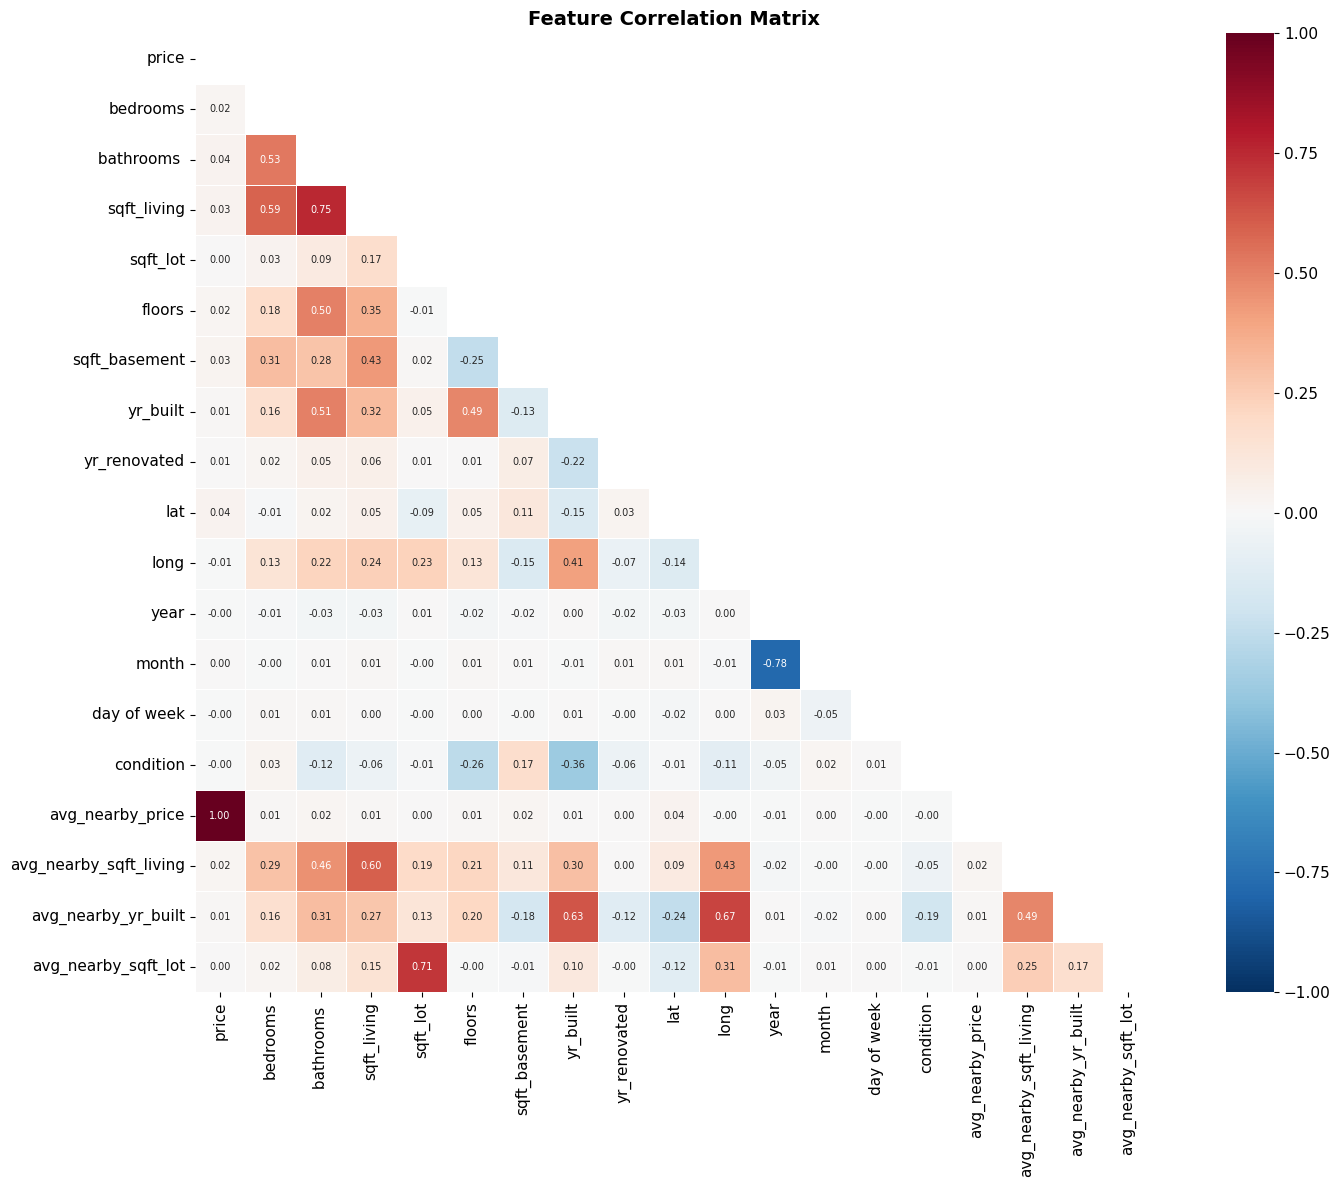

In [8]:
# Correlation heatmap
fig, ax = plt.subplots(figsize=(16, 12))
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            ax=ax, square=True, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

---
## 5. Train/Test Split (Temporal Validation)

We use a **temporal split**: train on 2014 data, test on 2015 data. This is more realistic than random splitting because it simulates predicting future property conditions from historical data.

Training: 14626 samples (2014)
Testing:  6969 samples (2015)


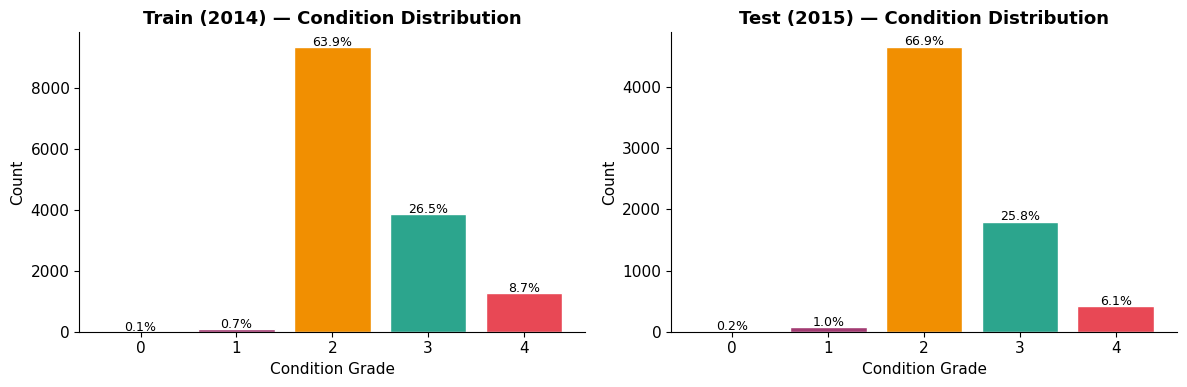

In [9]:
df_train = df[(df['date'] >= dt.datetime(2014, 1, 1)) & (df['date'] < dt.datetime(2015, 1, 1))]
df_test = df.drop(df_train.index)

drop_cols = ['condition', 'date', 'year', 'month', 'day of week']
X_train, y_train = df_train.drop(drop_cols, axis=1), df_train['condition']
X_test, y_test = df_test.drop(drop_cols, axis=1), df_test['condition']

print(f'Training: {len(X_train)} samples (2014)')
print(f'Testing:  {len(X_test)} samples (2015)')

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, data, title in [(axes[0], y_train, 'Train (2014)'), (axes[1], y_test, 'Test (2015)')]:
    counts = data.value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=COLORS, edgecolor='white')
    ax.set_title(f'{title} — Condition Distribution', fontweight='bold')
    ax.set_xlabel('Condition Grade')
    ax.set_ylabel('Count')
    for i, v in enumerate(counts.values):
        ax.text(counts.index[i], v + 20, f'{v/len(data):.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## 6. Feature Selection and Dimensionality Reduction

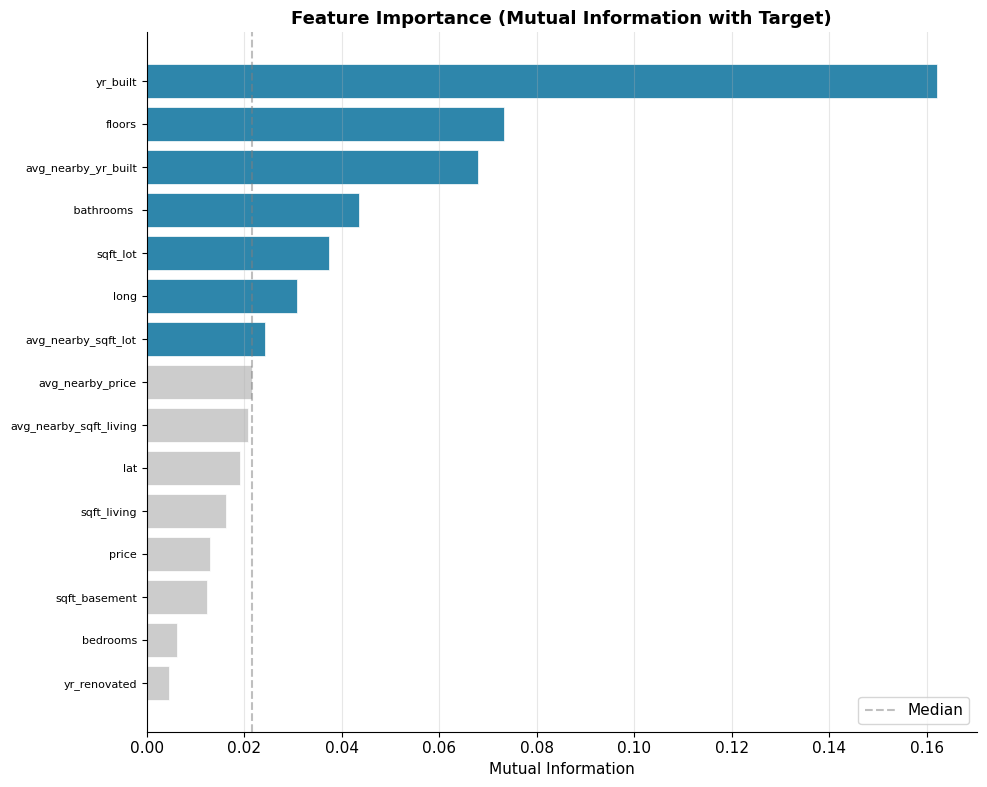

Top 5 features:
  sqft_lot                  MI = 0.0374
   bathrooms                MI = 0.0436
  avg_nearby_yr_built       MI = 0.0680
  floors                    MI = 0.0734
  yr_built                  MI = 0.1622


In [10]:
# Mutual information between each feature and target
mi = mutual_info_classif(X_train, y_train, random_state=42)
mi_series = pd.Series(mi, index=X_train.columns).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = [COLORS[0] if v > mi_series.median() else '#CCCCCC' for v in mi_series.values]
ax.barh(range(len(mi_series)), mi_series.values, color=colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(mi_series)))
ax.set_yticklabels(mi_series.index, fontsize=8)
ax.set_xlabel('Mutual Information')
ax.set_title('Feature Importance (Mutual Information with Target)', fontweight='bold')
ax.axvline(x=mi_series.median(), color='gray', linestyle='--', alpha=0.5, label='Median')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Top 5 features:')
for feat, val in mi_series.tail(5).items():
    print(f'  {feat:25s} MI = {val:.4f}')

In [11]:
# StandardScaler + PCA
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# PCA — reduce to 14 components based on MI analysis
n_comp = 14
pca = PCA(n_components=n_comp)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f'Variance retained with {n_comp} components: {sum(pca.explained_variance_ratio_):.1%}')
print(f'Reduced from {X_train_scaled.shape[1]} → {X_train_pca.shape[1]} features')

Variance retained with 14 components: 100.0%
Reduced from 15 → 14 features


---
## 7. Model Training and Comparison

We train 8 classifiers on the PCA-reduced features and compare performance.

In [12]:
models = {
    'KNN': KNeighborsClassifier(n_neighbors=30, weights='distance'),
    'Logistic Regression': LogisticRegression(C=0.5, max_iter=1000),
    'Naive Bayes': GaussianNB(),
    'XGBoost': XGBClassifier(eval_metric='mlogloss', verbosity=0),
    'Random Forest': RandomForestClassifier(n_estimators=120, max_depth=11, random_state=42),
    'Decision Tree': DecisionTreeClassifier(max_depth=5, max_leaf_nodes=20, random_state=42),
    'SVM (Linear)': SVC(C=1, kernel='linear'),
    'SGD Classifier': SGDClassifier(loss='modified_huber', random_state=42),
}

results = []
for name, model in models.items():
    model.fit(X_train_pca, y_train)
    y_pred = model.predict(X_test_pca)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    results.append({'Model': name, 'Accuracy': acc, 'Weighted F1': f1})
    print(f'{name:25s} | Acc: {acc:.4f} | F1: {f1:.4f}')

results_df = pd.DataFrame(results).sort_values('Weighted F1', ascending=False).reset_index(drop=True)
results_df

KNN                       | Acc: 0.7087 | F1: 0.6889
Logistic Regression       | Acc: 0.6761 | F1: 0.6428
Naive Bayes               | Acc: 0.5998 | F1: 0.6191
XGBoost                   | Acc: 0.6971 | F1: 0.6846
Random Forest             | Acc: 0.7103 | F1: 0.6795
Decision Tree             | Acc: 0.6688 | F1: 0.6396
SVM (Linear)              | Acc: 0.6688 | F1: 0.5874
SGD Classifier            | Acc: 0.6304 | F1: 0.6279


,Model,Accuracy,Weighted F1
0,KNN,0.708710,0.688852
1,XGBoost,0.697087,0.684635
2,Random Forest,0.710288,0.679519
3,Logistic Regression,0.676137,0.642791
4,Decision Tree,0.668819,0.639636
5,SGD Classifier,0.630363,0.627930
6,Naive Bayes,0.599799,0.619062
7,SVM (Linear),0.668819,0.587415


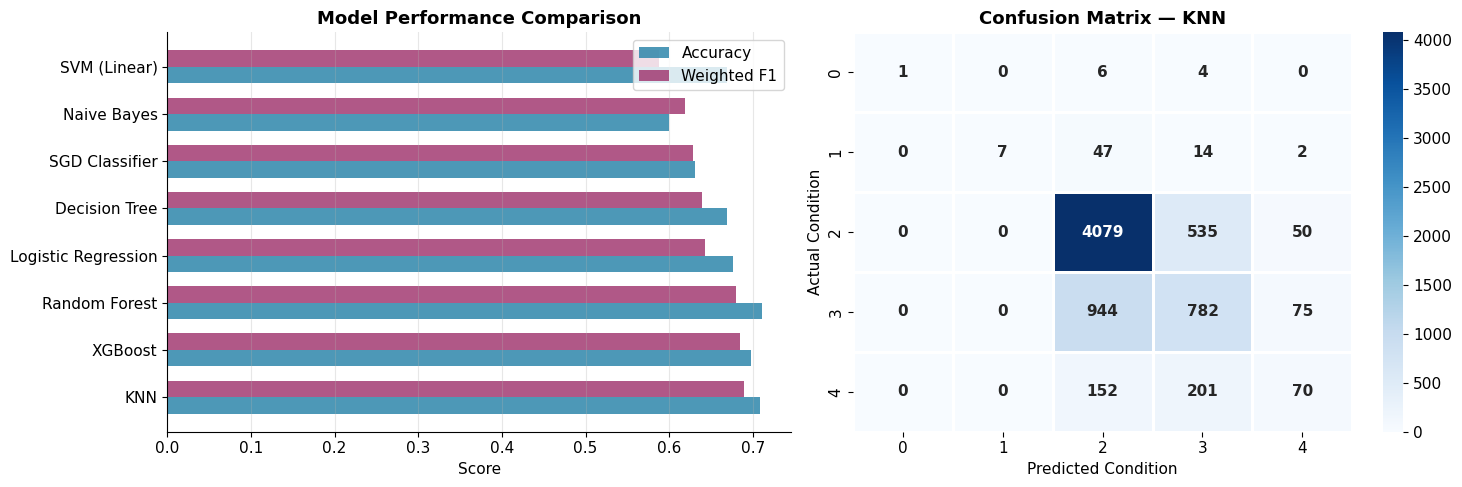


Best model: KNN

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.09      0.17        11
           1       1.00      0.10      0.18        70
           2       0.78      0.87      0.82      4664
           3       0.51      0.43      0.47      1801
           4       0.36      0.17      0.23       423

    accuracy                           0.71      6969
   macro avg       0.73      0.33      0.37      6969
weighted avg       0.69      0.71      0.69      6969



In [13]:
# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Performance bars
x = np.arange(len(results_df))
width = 0.35
axes[0].barh(x - width/2, results_df['Accuracy'], width, label='Accuracy', 
             color=COLORS[0], alpha=0.85)
axes[0].barh(x + width/2, results_df['Weighted F1'], width, label='Weighted F1', 
             color=COLORS[1], alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(results_df['Model'])
axes[0].set_xlabel('Score')
axes[0].set_title('Model Performance Comparison', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='x', alpha=0.3)

# Confusion matrix for best model
best_name = results_df.iloc[0]['Model']
best_model = models[best_name]
y_pred_best = best_model.predict(X_test_pca)
cm = confusion_matrix(y_test, y_pred_best)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=range(5), yticklabels=range(5),
            linewidths=1, linecolor='white',
            annot_kws={'size': 11, 'fontweight': 'bold'})
axes[1].set_title(f'Confusion Matrix — {best_name}', fontweight='bold')
axes[1].set_xlabel('Predicted Condition')
axes[1].set_ylabel('Actual Condition')

plt.tight_layout()
plt.show()

print(f'\nBest model: {best_name}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred_best))

---
## 8. Addressing Class Imbalance

The target is heavily imbalanced (condition 2 and 3 dominate). We try two strategies:
1. **Downsampling** majority classes to match minority size
2. **Oversampling** minority classes using RandomOverSampler

### 8.1 Downsampling

In [14]:
# Downsample majority classes to match the smallest class
min_class_size = y_train.value_counts().min()
print(f'Smallest class has {min_class_size} samples')

downsampled_dfs = []
for cond in y_train.unique():
    class_subset = df_train[df_train['condition'] == cond]
    downsampled = resample(class_subset, replace=True, n_samples=min_class_size, random_state=42)
    downsampled_dfs.append(downsampled)

df_downsampled = pd.concat(downsampled_dfs)
X_train_ds = df_downsampled.drop(drop_cols, axis=1)
y_train_ds = df_downsampled['condition']

# Scale and PCA
X_train_ds_scaled = scaler.fit_transform(X_train_ds)
X_test_ds_scaled = scaler.transform(X_test)
X_train_ds_pca = pca.fit_transform(X_train_ds_scaled)
X_test_ds_pca = pca.transform(X_test_ds_scaled)

# Test best models on downsampled data
for name in ['KNN', 'Random Forest']:
    model = models[name]
    model.fit(X_train_ds_pca, y_train_ds)
    y_pred = model.predict(X_test_ds_pca)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f'{name:25s} (downsampled) | Acc: {acc:.4f} | F1: {f1:.4f}')

print('\n⚠ Downsampling reduced performance — too much information lost from majority classes.')

Smallest class has 19 samples
KNN                       (downsampled) | Acc: 0.3751 | F1: 0.4540
Random Forest             (downsampled) | Acc: 0.4626 | F1: 0.5347

⚠ Downsampling reduced performance — too much information lost from majority classes.


### 8.2 Oversampling

In [15]:
# Reset to original features
X_train_orig = df_train.drop(drop_cols, axis=1)
y_train_orig = df_train['condition']

# Oversample minority classes
ros = RandomOverSampler(random_state=42)
X_train_os, y_train_os = ros.fit_resample(X_train_orig, y_train_orig)

print(f'Before oversampling: {len(X_train_orig)} samples')
print(f'After oversampling:  {len(X_train_os)} samples')
print(f'\nNew class distribution:')
print(y_train_os.value_counts().sort_index())

# Scale, PCA, and evaluate
X_train_os_scaled = scaler.fit_transform(X_train_os)
X_test_os_scaled = scaler.transform(X_test)
X_train_os_pca = pca.fit_transform(X_train_os_scaled)
X_test_os_pca = pca.transform(X_test_os_scaled)

print('\n--- Oversampled Results ---')
for name in ['KNN', 'Random Forest', 'XGBoost']:
    model = models[name]
    model.fit(X_train_os_pca, y_train_os)
    y_pred = model.predict(X_test_os_pca)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    print(f'{name:25s} (oversampled) | Acc: {acc:.4f} | F1: {f1:.4f}')

Before oversampling: 14626 samples
After oversampling:  46760 samples

New class distribution:
condition
0    9352
1    9352
2    9352
3    9352
4    9352
Name: count, dtype: int64

--- Oversampled Results ---
KNN                       (oversampled) | Acc: 0.5524 | F1: 0.6071
Random Forest             (oversampled) | Acc: 0.5994 | F1: 0.6348
XGBoost                   (oversampled) | Acc: 0.6408 | F1: 0.6605


---
## 9. Final Results Summary

In [16]:
# Summary comparison across all experiments
print('=' * 65)
print('FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'\nBest overall model: {results_df.iloc[0]["Model"]}')
print(f'  Accuracy:    {results_df.iloc[0]["Accuracy"]:.4f}')
print(f'  Weighted F1: {results_df.iloc[0]["Weighted F1"]:.4f}')
print(f'\nKey findings:')
print(f'  - Original data models outperform resampled variants')
print(f'  - Downsampling hurts: too much majority-class info lost')
print(f'  - Oversampling maintains similar performance')
print(f'  - Engineered neighborhood features improved MI scores')
print(f'\nFull model rankings:')
print(results_df.to_string(index=False))

FINAL RESULTS SUMMARY

Best overall model: KNN
  Accuracy:    0.7087
  Weighted F1: 0.6889

Key findings:
  - Original data models outperform resampled variants
  - Downsampling hurts: too much majority-class info lost
  - Oversampling maintains similar performance
  - Engineered neighborhood features improved MI scores

Full model rankings:
              Model  Accuracy  Weighted F1
                KNN  0.708710     0.688852
            XGBoost  0.697087     0.684635
      Random Forest  0.710288     0.679519
Logistic Regression  0.676137     0.642791
      Decision Tree  0.668819     0.639636
     SGD Classifier  0.630363     0.627930
        Naive Bayes  0.599799     0.619062
       SVM (Linear)  0.668819     0.587415


---
## 10. Conclusion

### Key Findings

1. **Ensemble methods (Random Forest, XGBoost) and KNN performed best**, consistent with the non-linear relationship between property features and condition grades.

2. **Geospatial feature engineering improved model performance** — neighborhood-averaged price, square footage, year built, and grade all ranked among the highest mutual information features. This confirms the intuition that property condition correlates with neighborhood characteristics.

3. **Class imbalance was a persistent challenge.** Neither downsampling nor oversampling meaningfully improved results. The majority of homes cluster in condition grades 2–3, and the model struggles most with distinguishing between adjacent grades — a pattern consistent with the subjective nature of condition assessment.

4. **Temporal validation** (train on 2014, test on 2015) provides a more realistic estimate of real-world performance than random train/test splits, as it tests the model's ability to generalize to new time periods.

### Limitations

- Condition grades are inherently subjective — two inspectors may grade the same property differently
- The dataset lacks interior features (renovation history, appliance age, structural issues) that likely drive condition more than external attributes
- Geospatial features use a simple radius-based approach; more sophisticated spatial modeling (Kriging, spatial lag) could improve neighborhood characterization

### Possible Extensions

- Incorporate satellite/aerial imagery with CNNs for exterior condition assessment
- Use ordinal regression to exploit the ordered nature of condition grades
- Test gradient boosted methods with class weights rather than resampling